# Notebook 08: Explainability with Qwen-3

Loads the trained uncertainty model from Notebook 07, runs inference on five
representative test-set records, computes gradient saliency maps, then feeds
the structured output to **Qwen3-0.6B** for a plain-language clinical interpretation.

All reusable logic lives in **`src/explainability/`** (`saliency.py`, `visualize.py`, `llm.py`).

**Cells run in order.** Requires `results/uncertainty_model/` from Notebook 07.
Qwen3 downloads ~400 MB on first run.

In [1]:
import sys, os, json, warnings, time
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE']            = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
warnings.filterwarnings('ignore')

import numpy as np
import torch
import pandas as pd

from src.utils.config               import CFG
from src.models.uncertainty_head    import AleatoricWrapper
from src.inference.pipeline         import ECGInferencePipeline
from src.inference.loaders          import load_hubert_blocks, load_hubert_peft, load_leadwise
from src.data.label_utils  import load_all_labels
from src.data.dataset_full import ECGDatasetFull
from src.explainability.saliency    import compute_saliency, top_salient_leads
from src.explainability.visualize   import plot_ecg_with_saliency
from src.explainability.llm         import (
    safe_print, load_qwen3, build_ecg_prompt, generate_explanation
)

DATA_PATH    = CFG['data']['path']
RESULTS      = CFG['paths']['results']
FIGURES      = CFG['paths']['figures']
SUPERCLASSES = CFG['data']['superclasses']
LEAD_NAMES   = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(FIGURES, exist_ok=True)
os.makedirs(os.path.join(RESULTS, 'explainability'), exist_ok=True)

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU: not available -- running on CPU')

GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
analysis_path = os.path.join(RESULTS, 'uncertainty_model', 'uncertainty_analysis.json')
assert os.path.exists(analysis_path), f'Missing {analysis_path} -- run Notebook 07 first.'
analysis = json.load(open(analysis_path))

BASE_NAME = analysis['base_model_name']
BASE_AUC  = analysis['base_model_auc']
UNC_AUC   = analysis['uncertainty_model_auc']
print(f'Base model            : {BASE_NAME}  (AUC {BASE_AUC:.4f})')
print(f'Uncertainty model AUC : {UNC_AUC:.4f}')
print()

LOADER_MAP = {
    'hubert_ecg_blocks8':   (lambda: load_hubert_blocks(n=8),                 CFG['model']['hubert_hidden_dim']),
    'hubert_ecg_dora_r8':   (lambda: load_hubert_peft(rank=8, use_dora=True), CFG['model']['hubert_hidden_dim']),
    'hubert_ecg_lora_r8':   (lambda: load_hubert_peft(rank=8, use_dora=False),CFG['model']['hubert_hidden_dim']),
    'leadwise_transformer': (lambda: load_leadwise(),                          CFG['model']['leadwise']['d_model']),
}

loader_fn, hidden_dim = LOADER_MAP[BASE_NAME]
base_model, _         = loader_fn()

uncertainty_model = AleatoricWrapper(base_model, hidden_dim=hidden_dim)
ckpt_path = os.path.join(RESULTS, 'uncertainty_model', 'best_adapter', 'checkpoint.pt')
uncertainty_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
uncertainty_model.eval()
print(f'Uncertainty model loaded from {ckpt_path}')

Base model            : hubert_ecg_blocks8  (AUC 0.8826)
Uncertainty model AUC : 0.7518

Loading HuBERT-ECG-base...
Loaded.
Unfrozen 128 tensors from last 8 blocks (layers 4–11)
Trainable: 56,902,661 / 93,323,397 (61.0%)
Uncertainty model loaded from D:\GitHub\biosignal-xai\results/uncertainty_model\best_adapter\checkpoint.pt


In [3]:
Y       = load_all_labels(DATA_PATH + 'ptbxl_database.csv',
                          DATA_PATH + 'scp_statements.csv')
test_df = Y[Y.strat_fold == 10]
test_ds = ECGDatasetFull(test_df, DATA_PATH)

pipeline = ECGInferencePipeline(uncertainty_model.to(device), has_uncertainty=True)

N_SCAN = min(200, len(test_ds))
print(f'Scanning {N_SCAN} test records...')

scan_results = []
for i in range(N_SCAN):
    x, y_true = test_ds[i]
    result    = pipeline.predict(x.numpy())
    true_cls  = [SUPERCLASSES[j] for j, v in enumerate(y_true) if v == 1]
    correct   = any(c in result['predicted_classes'] for c in true_cls)
    scan_results.append({
        'idx':        i,
        'uncertainty':result['uncertainty'],
        'confidence': result['confidence_score'],
        'correct':    correct,
        'true_cls':   true_cls,
        'pred_cls':   result['predicted_classes'],
        'probs':      result['class_probabilities'],
        'unc_level':  result['uncertainty_level'],
        'result':     result,
    })

df_scan = pd.DataFrame(scan_results)
_corr   = df_scan[df_scan['correct'] == True]
_wrong  = df_scan[df_scan['correct'] == False]
_multi  = df_scan[df_scan['true_cls'].apply(len) > 1]

case_indices = {
    'Correct + Low Uncertainty':  _corr.nsmallest(1,  'uncertainty')['idx'].iloc[0],
    'Correct + High Uncertainty': _corr.nlargest(1,   'uncertainty')['idx'].iloc[0],
    'Wrong + High Uncertainty':   (_wrong.nlargest(1, 'uncertainty')['idx'].iloc[0] if len(_wrong) > 0 else 0),
    'Wrong + Low Uncertainty':    (_wrong.nsmallest(1,'uncertainty')['idx'].iloc[0] if len(_wrong) > 0 else 1),
    'Multi-label':                (_multi['idx'].iloc[0] if len(_multi) > 0 else 2),
}

print('Selected cases:')
for label, idx in case_indices.items():
    row = df_scan.loc[idx]
    print(f'  [{label}]  idx={idx}  '
          f'true={row["true_cls"]}  pred={row["pred_cls"]}  '
          f'conf={row["confidence"]:.2f}  unc={row["uncertainty"]:.4f}')

Records with valid labels: 21388
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5235 (24.5%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Scanning 200 test records...
Selected cases:
  [Correct + Low Uncertainty]  idx=10  true=['NORM']  pred=['NORM']  conf=0.89  unc=0.4333
  [Correct + High Uncertainty]  idx=42  true=['STTC']  pred=['STTC']  conf=0.61  unc=1.1152
  [Wrong + High Uncertainty]  idx=146  true=['MI', 'CD']  pred=['STTC']  conf=0.61  unc=1.1206
  [Wrong + Low Uncertainty]  idx=6  true=['CD']  pred=['NORM']  conf=0.84  unc=0.5515
  [Multi-label]  idx=24  true=['MI', 'STTC', 'CD', 'HYP']  pred=['STTC']  conf=0.57  unc=1.0929


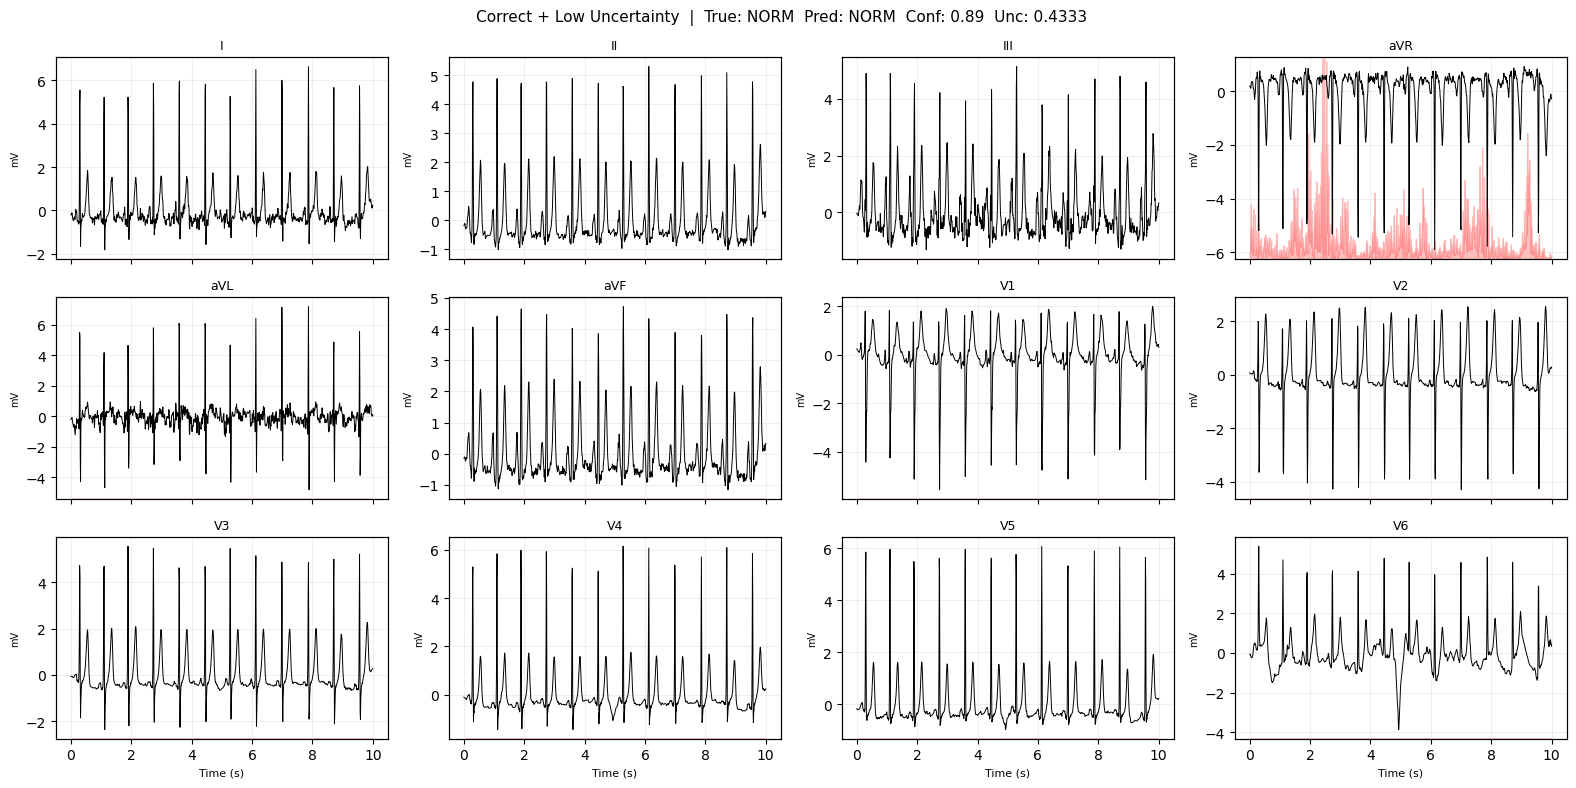

  Correct + Low Uncertainty  |  top leads: ['aVR', 'aVL', 'aVF']


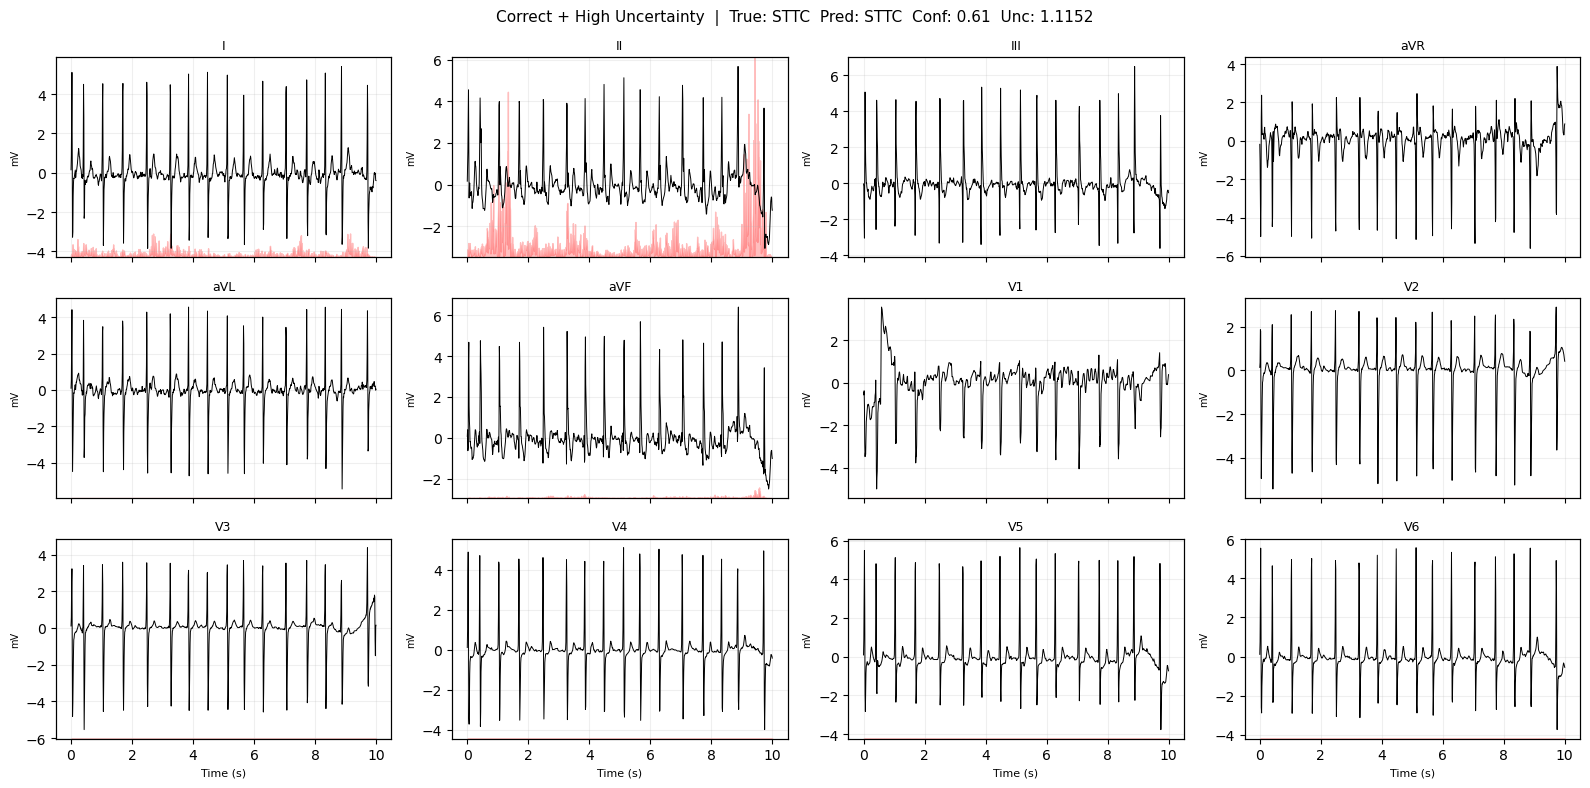

  Correct + High Uncertainty  |  top leads: ['II', 'I', 'aVF']


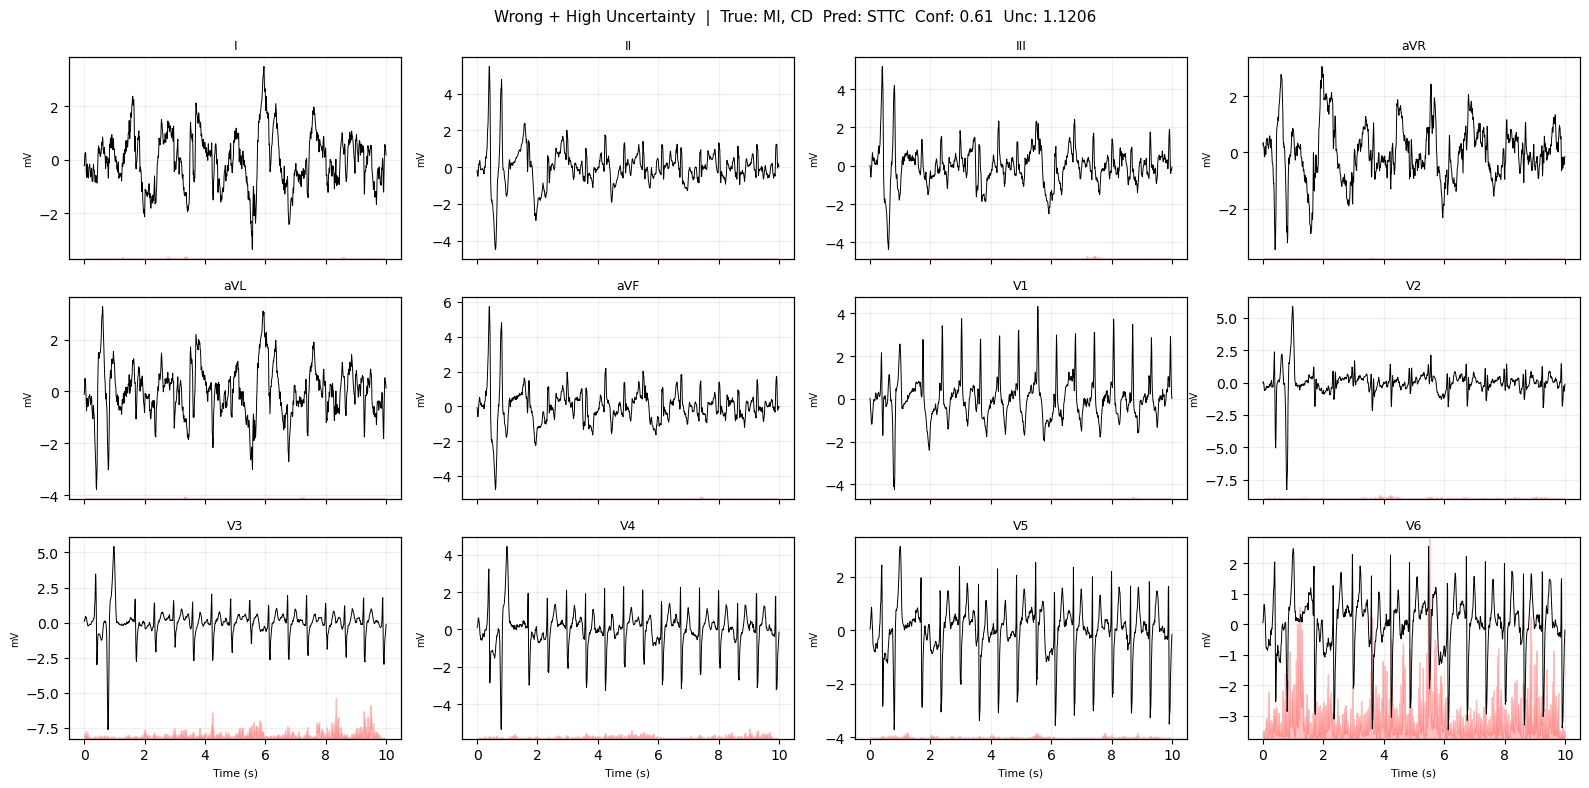

  Wrong + High Uncertainty  |  top leads: ['V6', 'V3', 'V4']


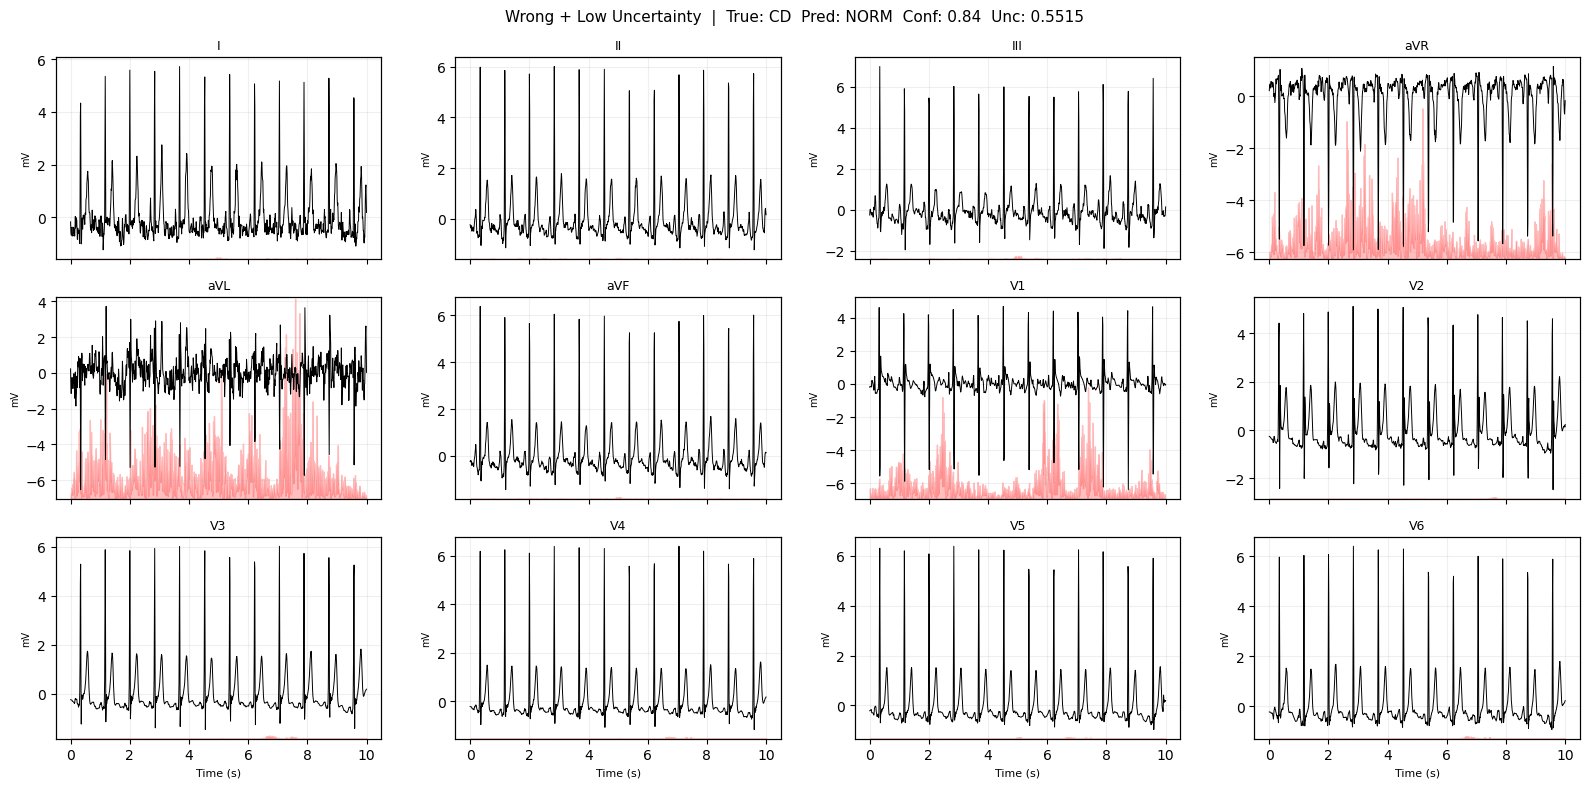

  Wrong + Low Uncertainty  |  top leads: ['aVL', 'aVR', 'V1']


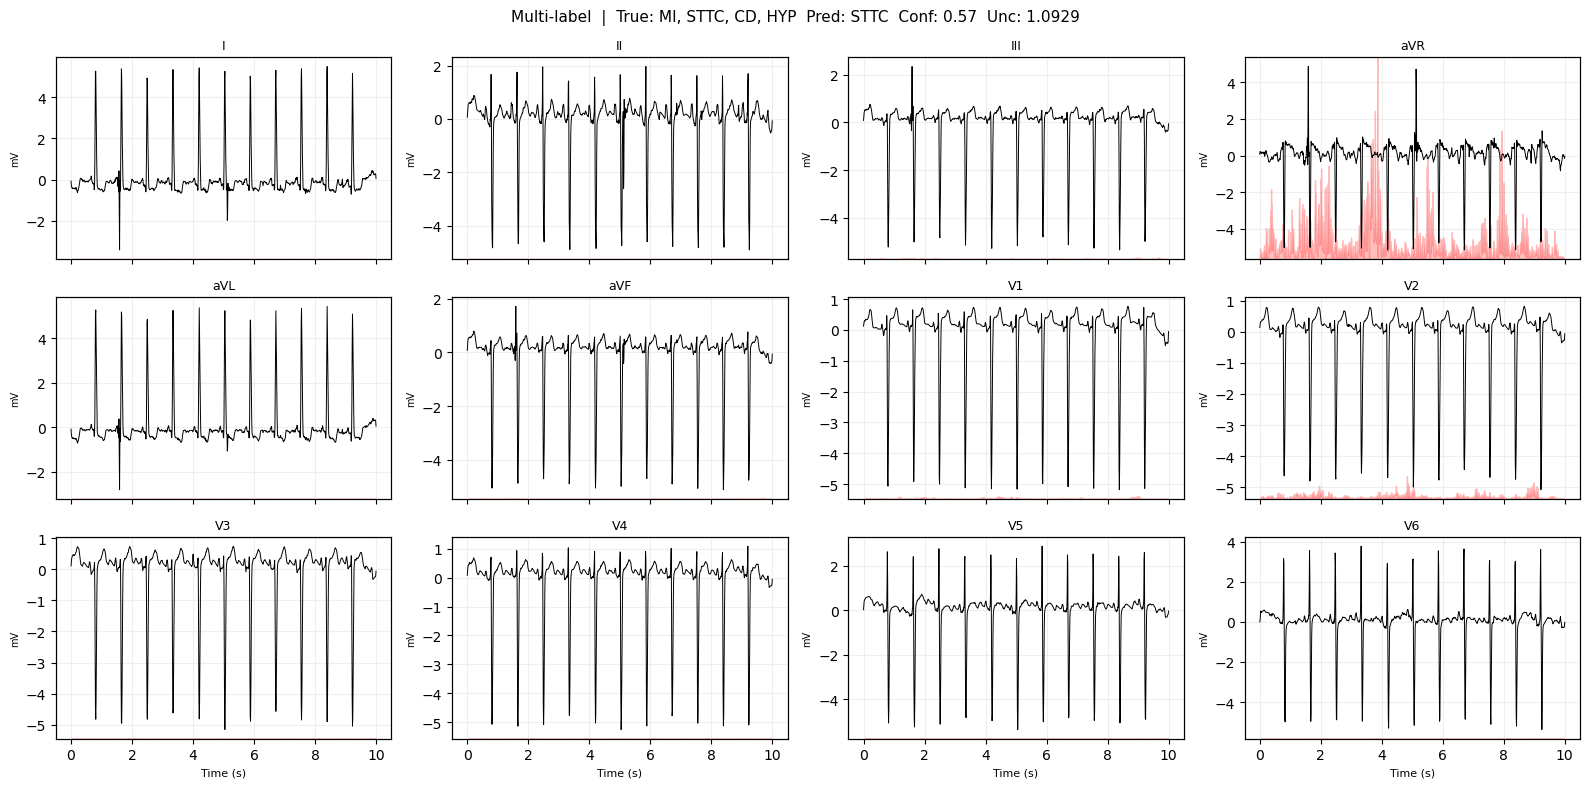

  Multi-label  |  top leads: ['aVR', 'V2', 'V1']


In [4]:
import matplotlib
case_saliencies = {}

for case_label, idx in case_indices.items():
    row  = df_scan.loc[idx]
    x, _ = test_ds[idx]
    x_np = x.numpy()   # (12, 1000)

    target_idx = int(np.argmax([row['probs'][c] for c in SUPERCLASSES]))
    saliency   = compute_saliency(uncertainty_model, x_np, target_idx, device)
    case_saliencies[case_label] = saliency

    pred_info = {
        'true_cls':   row['true_cls'],
        'pred_cls':   row['pred_cls'],
        'confidence': row['confidence'],
        'uncertainty':row['uncertainty'],
    }
    safe_slug  = case_label.replace(' ', '_').replace('+', 'plus')
    fig_path   = os.path.join(FIGURES, f'saliency_{safe_slug}.png')
    plot_ecg_with_saliency(
        x_np, saliency, title=case_label,
        pred_info=pred_info, lead_names=LEAD_NAMES,
        save_path=fig_path,
    )
    leads = top_salient_leads(saliency, LEAD_NAMES)
    print(f'  {case_label}  |  top leads: {leads}')

In [6]:
# Free ECG model from GPU, then switch online for Qwen3
uncertainty_model.cpu()
torch.cuda.empty_cache()

os.environ['TRANSFORMERS_OFFLINE'] = '0'

QWEN_MODEL = 'Qwen/Qwen3-0.6B'
qwen_model, qwen_tokenizer = load_qwen3(QWEN_MODEL)

Loading Qwen/Qwen3-0.6B ...


OSError: We couldn't connect to 'https://huggingface.co' to load this file, couldn't find it in the cached files and it looks like Qwen/Qwen3-0.6B is not the path to a directory containing a file named config.json.
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

In [ ]:
explanations = {}
for case_label, idx in case_indices.items():
    row      = df_scan.loc[idx]
    saliency = case_saliencies[case_label]
    prompt   = build_ecg_prompt(
        row['result'], saliency, LEAD_NAMES,
        superclasses=SUPERCLASSES, true_classes=row['true_cls'],
    )
    t0  = time.perf_counter()
    exp = generate_explanation(prompt, qwen_model, qwen_tokenizer)
    dt  = time.perf_counter() - t0

    explanations[case_label] = exp
    print(f'\n[{case_label}]  ({dt:.1f}s)')
    safe_print(exp)

In [ ]:
SEP = '=' * 70
for case_label, idx in case_indices.items():
    row   = df_scan.loc[idx]
    probs = row['probs']

    print(SEP)
    print(f'CASE: {case_label}')
    print(SEP)
    print(f'  True diagnosis  : {", ".join(row["true_cls"]) or "None"}')
    print(f'  Predicted class : {", ".join(row["pred_cls"])}')
    print(f'  Probabilities   : ' + '  '.join(f'{c}:{probs[c]:.3f}' for c in SUPERCLASSES))
    print(f'  Confidence      : {row["confidence"]:.3f}')
    print(f'  Uncertainty     : {row["uncertainty"]:.4f}  ({row["unc_level"]})')
    print(f'  Correct         : {"Yes" if row["correct"] else "No"}')
    print(f'  Top leads       : {top_salient_leads(case_saliencies[case_label], LEAD_NAMES)}')
    print()
    print('  -- Qwen3 Explanation --')
    for line in explanations.get(case_label, '(not generated)').splitlines():
        safe_print(f'  {line}')
    print()

In [ ]:
report = []
for case_label, idx in case_indices.items():
    row      = df_scan.loc[idx]
    saliency = case_saliencies[case_label]
    report.append({
        'case_type':          case_label,
        'test_set_idx':       int(idx),
        'true_classes':       row['true_cls'],
        'predicted_classes':  row['pred_cls'],
        'class_probabilities':row['probs'],
        'confidence':         float(row['confidence']),
        'uncertainty':        float(row['uncertainty']),
        'uncertainty_level':  row['unc_level'],
        'correct':            bool(row['correct']),
        'top_salient_leads':  top_salient_leads(saliency, LEAD_NAMES),
        'qwen3_explanation':  explanations.get(case_label, ''),
        'qwen3_model':        QWEN_MODEL,
    })

out_path = os.path.join(RESULTS, 'explainability', 'explanations.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump({'base_model': BASE_NAME, 'cases': report}, f, indent=2, ensure_ascii=False)

print(f'Saved -> {out_path}')
print(f'{len(report)} cases recorded.')